# XGBoost–LSTM Hybrid Model for Wind Speed Forecasting
## Multivariate Standalone Optimal Model with Residual Correction
### Sections: Original Model | Grid Search | Randomized Search | Optuna

**Methodology Overview:**
1. An XGBoost primary model (pre-tuned via Optuna) generates wind-speed forecasts.
2. The residuals from XGBoost are modelled by an LSTM residual-correction network.
3. The hybrid forecast is: **Ŷ_hybrid = Ŷ_XGB + Ŷ_LSTM_residual**
4. All hyperparameter searches use the first 80% of data (training set) with
   TimeSeriesSplit cross-validation — the held-out last 20% is never seen during tuning.


## 1. Installing Required Packages

In [ ]:
!pip install -U scikit-learn scikeras

!pip install scikeras

import sklearn
import scikeras

print("scikit-learn version:", sklearn.__version__)
print("scikeras version:", scikeras.__version__)
#scikit-learn >= 1.2.0
#scikeras >= 0.10.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 56.5 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
scikit-learn version: 1.9.0
scikeras version: 0.13.0


In [ ]:
# INSTALLING REQUIRED PACKAGES
!pip install statsmodels optuna tabulate xgboost scikeras --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 16.0 MB/s eta 0:00:00


## 2. Imports & Global Settings

In [ ]:
# Standard libraries
import sys
import os
import warnings
import random
warnings.filterwarnings("ignore")

# Data manipulation
import numpy as np   # Numerical operations
import pandas as pd  # Data manipulation and analysis

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Preprocessing & model selection
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (TimeSeriesSplit, GridSearchCV,
                                     RandomizedSearchCV)
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score)
from sklearn.inspection import permutation_importance
from scipy.stats import randint, uniform

# XGBoost
import xgboost as xgb

# TensorFlow / Keras (LSTM)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# SciKeras wrapper (scikit-learn API for Keras)
from scikeras.wrappers import KerasRegressor

# Optuna (Bayesian hyperparameter optimisation)
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress verbose trial logs

# ── Global random seed (set once; reused throughout) ──────────────────────────
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
print(f"Global random seed set to {RANDOM_SEED}")


Global random seed set to 42


## 3. Loading the Dataset

In [ ]:
# =============================================================================
# LOADING THE DATASET
# Dataset sources:
#   https://drive.google.com/file/d/1Z_KsoIumw-fvivVombIoWuRo0LOe2nCb/view?usp=sharing
#   https://drive.google.com/file/d/1aD1PXfwEEZ_F2lQgxuPfj-TVbxQ6NajK/view?usp=sharing
# =============================================================================

file_id      = "1c5KmcFD1TOsqASqzy0KiYo-7IzgBFuhk"   # Variable Set 2 dataset
download_url = f"https://drive.google.com/uc?id={file_id}"

df = pd.read_csv(download_url)

# Create a proper datetime index from year / month / day columns
df['Date'] = pd.to_datetime({
    'year':  df['YEAR'],
    'month': df['MO'],
    'day':   df['DY']
})
df = df.set_index('Date')

# Drop the raw date columns (now encoded in the index)
df = df.drop(columns=["YEAR", "MO", "DY"])

print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
display(df.head())
print("\nColumns:", df.columns.tolist())


Dataset loaded successfully.
Shape: (4015, 14)

First 5 rows:


,WS10M_lag1,RH,MIN_TEMP,PREC,WD_sin,SURF_PRESSURE_DIFF,AVG_TEMP,WD_cos,RH_lag1,MONOSOON_SEASON_Southwest_Monsoon,MAX_TEMP,SL_PRESSURE_lag1,CLOUD_COVER,WS10M
Date,,,,,,,,,,,,,,
2013-01-03,4.25,86.26,23.42,13.42,0.439939,0.03,26.4,0.898028,86.19,0,28.38,1010.4,8.0,4.75
2013-01-04,4.75,86.31,22.93,8.79,0.424199,-0.03,25.1,0.905569,86.26,0,27.58,1011.0,8.0,5.74
2013-01-05,5.74,86.88,22.17,2.60,0.563526,-0.15,26.9,0.826098,86.31,0,26.16,1010.1,8.0,5.79
2013-01-06,5.79,88.09,23.47,1.65,0.460200,-0.03,27.3,0.887815,86.88,0,27.75,1007.5,7.0,4.52
2013-01-07,4.52,93.04,24.04,27.41,0.368125,-0.01,25.9,0.929776,88.09,0,26.70,1008.2,8.0,4.66



Columns: ['WS10M_lag1', 'RH', 'MIN_TEMP', 'PREC', 'WD_sin', 'SURF_PRESSURE_DIFF', 'AVG_TEMP', 'WD_cos', 'RH_lag1', 'MONOSOON_SEASON_Southwest_Monsoon', 'MAX_TEMP', 'SL_PRESSURE_lag1', 'CLOUD_COVER', 'WS10M']


## 4. Primary Train–Test Split (80 / 20, Time-Based)

In [ ]:
# =============================================================================
# Train-test split — first 80% for training, last 20% for testing.
# Temporal ordering is strictly preserved; no shuffling is applied.
# =============================================================================

X = df.drop(columns=['WS10M'])  # Feature matrix
y = df['WS10M']                 # Target: wind speed (m/s)

split_index = int(len(X) * 0.8)  # 80% training, 20% testing

X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_test  = y.iloc[split_index:]

print(f"Total samples : {len(X)}")
print(f"Training set  : {X_train.shape}  (first {split_index} samples)")
print(f"Test set      : {X_test.shape}  (last {len(X) - split_index} samples)")
print(f"\nTrain period: {X_train.index[0].date()}  →  {X_train.index[-1].date()}")
print(f"Test period : {X_test.index[0].date()}  →  {X_test.index[-1].date()}")


Total samples : 4015
Training set  : (3212, 13)  (first 3212 samples)
Test set      : (803, 13)  (last 803 samples)

Train period: 2013-01-03  →  2021-10-19
Test period : 2021-10-20  →  2023-12-31


## 5. Shared Helper Functions

In [ ]:
# =============================================================================
# Helper functions used by all model sections below.
# Defined once here to avoid repetition.
# =============================================================================

def evaluate(y_true, y_pred, label=""):
    """Print and return evaluation metrics for the residual correction model."""
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)
    print(f"{label} MSE:  {mse:.4f}")
    print(f"{label} RMSE: {rmse:.4f}")
    print(f"{label} MAE:  {mae:.4f}")
    print(f"{label} MAPE: {mape:.2f}%")
    print(f"{label} R²:   {r2:.4f}")
    return mse, rmse, mae, mape, r2


def evaluate_performance(y_true, y_pred, set_name="Dataset"):
    """Evaluate and return metrics as a dictionary for the hybrid model."""
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)
    print(f"\n--- {set_name} Metrics ---")
    print(f"RMSE: {rmse:.4f}")
    print(f"MSE:  {mse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"MAPE: {mape:.4f}%")
    print(f"R²:   {r2:.4f}")
    return {'RMSE': rmse, 'MSE': mse, 'MAE': mae, 'MAPE': mape, 'R²': r2}


## 6. XGBoost Primary Model (Optuna-Optimised Parameters)

The XGBoost model was previously optimised with Optuna and achieved the
following standalone wind-speed forecasting performance:

| Method | Train MSE | Test MSE | Train MAE | Test MAE | Train RMSE | Test RMSE | Train MAPE (%) | Test MAPE (%) | Train R² | Test R² |
|--------|-----------|----------|-----------|----------|------------|-----------|----------------|---------------|----------|---------|
| Optuna | 0.211530  | 0.527328 | 0.360631  | 0.551346 | 0.459923   | 0.726173  | 9.983644       | 14.987060     | 0.916036 | 0.781323|


In [ ]:
# =============================================================================
# XGBoost Primary Model
# Best parameters sourced from prior Optuna optimisation run.
# The model is fitted on X_train only; predictions over the full dataset are
# stored so residuals can be computed for the LSTM correction layer.
# =============================================================================

# Best Parameters: {'n_estimators': 300, 'max_depth': 6,
#   'learning_rate': 0.02017215364230889, 'min_child_weight': 5,
#   'gamma': 0.019237778052053844, 'subsample': 0.618408743715084}
Best_Parameters = {
    'n_estimators':     300,
    'max_depth':        6,
    'learning_rate':    0.02017215364230889,
    'gamma':            0.019237778052053844,
    'subsample':        0.618408743715084,
    'min_child_weight': 5
}

# Initialise XGBRegressor with optimal parameters
best_xgb = xgb.XGBRegressor(**Best_Parameters, random_state=RANDOM_SEED)

# Fit on training data only (test set remains unseen until evaluation)
best_xgb.fit(X_train, y_train)
print(f"XGBoost fitted. Parameters: {Best_Parameters}")

# ── Train / Test predictions ──────────────────────────────────────────────────
y_train_pred_xgb = best_xgb.predict(X_train)
y_test_pred_xgb  = best_xgb.predict(X_test)

# ── Evaluation metrics ────────────────────────────────────────────────────────
xgb_train_mse  = mean_squared_error(y_train, y_train_pred_xgb)
xgb_test_mse   = mean_squared_error(y_test,  y_test_pred_xgb)
xgb_train_mae  = mean_absolute_error(y_train, y_train_pred_xgb)
xgb_test_mae   = mean_absolute_error(y_test,  y_test_pred_xgb)
xgb_train_rmse = np.sqrt(xgb_train_mse)
xgb_test_rmse  = np.sqrt(xgb_test_mse)
xgb_train_mape = np.mean(np.abs((y_train - y_train_pred_xgb) / y_train)) * 100
xgb_test_mape  = np.mean(np.abs((y_test  - y_test_pred_xgb)  / y_test))  * 100
xgb_train_r2   = r2_score(y_train, y_train_pred_xgb)
xgb_test_r2    = r2_score(y_test,  y_test_pred_xgb)

print(f"\nTrain MSE:  {xgb_train_mse:.4f}  | Test MSE:  {xgb_test_mse:.4f}")
print(f"Train MAE:  {xgb_train_mae:.4f}  | Test MAE:  {xgb_test_mae:.4f}")
print(f"Train RMSE: {xgb_train_rmse:.4f} | Test RMSE: {xgb_test_rmse:.4f}")
print(f"Train MAPE: {xgb_train_mape:.4f}%| Test MAPE: {xgb_test_mape:.4f}%")
print(f"Train R²:   {xgb_train_r2:.4f}  | Test R²:   {xgb_test_r2:.4f}")

# ── Summary table (Plotly) ────────────────────────────────────────────────────
summary_df = pd.DataFrame({
    'Parameter/Metric': list(Best_Parameters.keys()) +
                        ['Train MSE', 'Test MSE', 'Train MAE', 'Test MAE',
                         'Train RMSE', 'Test RMSE', 'Train MAPE (%)',
                         'Test MAPE (%)', 'Train R²', 'Test R²'],
    'Value': list(Best_Parameters.values()) +
             [xgb_train_mse, xgb_test_mse, xgb_train_mae, xgb_test_mae,
              xgb_train_rmse, xgb_test_rmse, xgb_train_mape, xgb_test_mape,
              xgb_train_r2, xgb_test_r2]
})
summary_df['Value'] = summary_df['Value'].apply(lambda x: f"{x:.6f}")

fig_table = go.Figure(go.Table(
    header=dict(
        values=['<b>Parameter / Metric</b>', '<b>Value</b>'],
        fill_color='steelblue',
        font=dict(color='white', size=13),
        align='left'
    ),
    cells=dict(
        values=[summary_df['Parameter/Metric'], summary_df['Value']],
        fill_color=[['lightcyan' if i % 2 == 0 else 'white'
                     for i in range(len(summary_df))]],
        align='left'
    )
))
fig_table.update_layout(
    title="XGBoost Optimal Parameters & Model Performance Metrics",
    template="plotly_white", height=600
)
fig_table.show()


XGBoost fitted. Parameters: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.02017215364230889, 'gamma': 0.019237778052053844, 'subsample': 0.618408743715084, 'min_child_weight': 5}

Train MSE:  0.2103  | Test MSE:  0.5259
Train MAE:  0.3590  | Test MAE:  0.5495
Train RMSE: 0.4586 | Test RMSE: 0.7252
Train MAPE: 9.9187%| Test MAPE: 14.9222%
Train R²:   0.9165  | Test R²:   0.7819


## 7. Out-of-Fold XGBoost Residuals (Training Set)

The residual-correction LSTM must learn to predict the errors XGBoost makes on
**unseen** data, because that is the only situation it will ever face in
deployment (XGBoost forecasts, then LSTM corrects). Predicting on the same
rows XGBoost was fitted on gives residuals that are systematically smaller
and differently shaped than genuine out-of-sample errors, since a boosted-
tree ensemble can partially fit noise in rows it has already seen. Training
the LSTM on those artificially small, in-sample residuals teaches it the
wrong correction pattern, and is a likely explanation for the small hybrid-
model gains observed previously.

The fix below generates **out-of-fold (OOF)** residuals for the training set
using the same `TimeSeriesSplit` scheme already used elsewhere in this
notebook for LSTM cross-validation. For every fold, a fresh XGBoost model is
fit only on data strictly before the fold and used to predict only that
fold -- so every training-set residual fed to the LSTM is, from that fold
model's perspective, a genuine out-of-sample residual. The test set is
untouched here; it was always out-of-sample because `best_xgb` never saw it
during fitting.


In [ ]:
# =============================================================================
# OUT-OF-FOLD (OOF) XGBOOST RESIDUALS ON THE TRAINING SET
# -----------------------------------------------------------------------------
# WHAT THIS CELL DOES
#   For each TimeSeriesSplit fold, we fit a FRESH XGBoost model (same tuned
#   hyperparameters as `best_xgb`) using only the rows strictly before the
#   fold's validation window, then predict on that validation window only.
#   Every prediction produced this way is out-of-sample with respect to the
#   model that produced it -- exactly like the situation at deployment time.
#
# WHY NOT JUST REUSE `best_xgb` (the model fit on the whole training set)?
#   `best_xgb` has already seen every training row during fitting, so its
#   predictions on those same rows are in-sample and would recreate the
#   original leakage problem. OOF cross-validation is the standard way to
#   obtain leakage-free "training set" predictions from a model that must
#   also be fit on the full training set for later deployment.
#
# THE UNAVOIDABLE GAP
#   TimeSeriesSplit needs an initial block of data to train the very first
#   fold, so the earliest rows of the training set (before the first fold's
#   validation window begins) never appear in any validation fold and cannot
#   get a leakage-free OOF prediction. We leave these as NaN here and drop
#   them explicitly later -- filling them with an in-sample prediction would
#   silently reintroduce the leakage this cell exists to remove.
# =============================================================================

N_SPLITS_OOF = 5  # same fold count used later for LSTM cross-validation
tscv_oof = TimeSeriesSplit(n_splits=N_SPLITS_OOF)

# Pre-allocate with NaN -- rows never selected as a validation fold (the
# initial training block) keep their NaN and are dropped further down.
oof_pred_train = np.full(shape=len(X_train), fill_value=np.nan)

print(f"Generating out-of-fold XGBoost predictions "
      f"({N_SPLITS_OOF}-fold TimeSeriesSplit) on {len(X_train)} training rows...\n")

for fold_i, (fold_train_idx, fold_val_idx) in enumerate(tscv_oof.split(X_train), start=1):
    # Fit a FRESH XGBoost (same tuned hyperparameters as best_xgb) using only
    # data strictly earlier than this fold's validation window.
    fold_model = xgb.XGBRegressor(**Best_Parameters, random_state=RANDOM_SEED)
    fold_model.fit(X_train.iloc[fold_train_idx], y_train.iloc[fold_train_idx])

    # Predict ONLY on the held-out fold -- genuinely out-of-sample for this model
    fold_val_pred = fold_model.predict(X_train.iloc[fold_val_idx])
    oof_pred_train[fold_val_idx] = fold_val_pred

    print(f"  Fold {fold_i}: fit on {len(fold_train_idx):>5} earlier rows -> "
          f"predicted {len(fold_val_idx):>5} held-out rows "
          f"(val idx {fold_val_idx[0]}:{fold_val_idx[-1]})")

n_missing = int(np.isnan(oof_pred_train).sum())
print(f"\nTraining rows with NO OOF prediction (initial block, dropped later): {n_missing}")
print(f"Training rows with a valid OOF prediction: {len(X_train) - n_missing} / {len(X_train)}")

# Out-of-fold residual = actual - OOF prediction (NaN where no OOF prediction exists)
oof_residual_train = y_train.values - oof_pred_train


Generating out-of-fold XGBoost predictions (5-fold TimeSeriesSplit) on 3212 training rows...

  Fold 1: fit on   537 earlier rows -> predicted   535 held-out rows (val idx 537:1071)
  Fold 2: fit on  1072 earlier rows -> predicted   535 held-out rows (val idx 1072:1606)
  Fold 3: fit on  1607 earlier rows -> predicted   535 held-out rows (val idx 1607:2141)
  Fold 4: fit on  2142 earlier rows -> predicted   535 held-out rows (val idx 2142:2676)
  Fold 5: fit on  2677 earlier rows -> predicted   535 held-out rows (val idx 2677:3211)

Training rows with NO OOF prediction (initial block, dropped later): 537
Training rows with a valid OOF prediction: 2675 / 3212


## 8. Combining OOF (Train) and Out-of-Sample (Test) Residuals


In [ ]:
# =============================================================================
# COMBINE OOF (TRAIN) + OUT-OF-SAMPLE (TEST) PREDICTIONS INTO ONE RESIDUAL SERIES
# -----------------------------------------------------------------------------
#   Train rows : the out-of-fold predictions computed in the cell above
#                (oof_pred_train). Each one is out-of-sample with respect to
#                the fold model that produced it.
#   Test rows  : predictions from `best_xgb`, the single model fit on the
#                FULL training set (already computed above as
#                y_test_pred_xgb). These were always genuinely out-of-sample
#                with respect to best_xgb, so nothing changes here.
#
# The resulting 'Residual' column is out-of-sample everywhere -- this is the
# target the LSTM residual-correction model is actually trained and
# evaluated against, instead of the old in-sample train residuals.
# =============================================================================

# Predictions used downstream: OOF for train rows, out-of-sample for test rows
y_pred_full_xgb = np.concatenate([oof_pred_train, y_test_pred_xgb])

df['Pred_XGB_Optuna'] = y_pred_full_xgb
df['Residual']        = df['WS10M'] - df['Pred_XGB_Optuna']

# Kept ONLY for comparison/diagnostics -- this is the old in-sample prediction
# from the model fit on the full training set. It is NOT used to train the
# LSTM; it lets the size of the leakage gap be inspected directly, e.g. by
# comparing 'Residual' against WS10M - Pred_XGB_Optuna_insample.
df['Pred_XGB_Optuna_insample'] = best_xgb.predict(X)

print("Predictions and OOF (train) / out-of-sample (test) residuals added to dataframe.")
print(f"NaN residuals (initial training block with no OOF fold coverage): "
      f"{int(df['Residual'].isna().sum())}")
print(df[['WS10M', 'Pred_XGB_Optuna', 'Residual']].head(10))
print(f"\nDataframe shape: {df.shape}")

# Backup the enriched dataframe -- this is the master reference for all hybrid models
df_backup = df.copy()

# -- Visualise actual vs predicted + residuals -------------------------------
fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=("Actual vs Predicted Wind Speed (OOF train / out-of-sample test)",
                     "Residuals (OOF train / out-of-sample test)"),
    shared_xaxes=True,
    vertical_spacing=0.12
)
fig.add_trace(go.Scatter(
    x=df.index, y=df['WS10M'],
    mode='lines', name='Actual WS10M',
    line=dict(color='steelblue', width=1.5)
), row=1, col=1)
fig.add_trace(go.Scatter(
    x=df.index, y=df['Pred_XGB_Optuna'],
    mode='lines', name='Predicted (OOF train / out-of-sample test)',
    line=dict(color='orange', width=1.5, dash='dot')
), row=1, col=1)
fig.add_trace(go.Scatter(
    x=df.index, y=df['Residual'],
    mode='lines', name='Residual',
    line=dict(color='crimson', width=1)
), row=2, col=1)
fig.add_hline(y=0, line_dash="dash", line_color="black", row=2, col=1)

fig.update_layout(
    height=700, template="plotly_white",
    title="XGBoost -- OOF (train) / Out-of-Sample (test) Predictions & Residuals",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)
fig.update_yaxes(title_text="Wind Speed (m/s)", row=1, col=1)
fig.update_yaxes(title_text="Residual",         row=2, col=1)
fig.update_xaxes(title_text="Date",             row=2, col=1)
fig.show()

# Save XGBoost predictions to CSV
df.to_csv('XGB_Primary_Model_Prediction.csv', index=True)
print("\nSaved to 'XGB_Primary_Model_Prediction.csv'")


Predictions and OOF (train) / out-of-sample (test) residuals added to dataframe.
NaN residuals (initial training block with no OOF fold coverage): 537
            WS10M  Pred_XGB_Optuna  Residual
Date                                        
2013-01-03   4.75              NaN       NaN
2013-01-04   5.74              NaN       NaN
2013-01-05   5.79              NaN       NaN
2013-01-06   4.52              NaN       NaN
2013-01-07   4.66              NaN       NaN
2013-01-08   3.61              NaN       NaN
2013-01-09   4.19              NaN       NaN
2013-01-10   5.41              NaN       NaN
2013-01-11   5.95              NaN       NaN
2013-01-12   5.80              NaN       NaN

Dataframe shape: (4015, 17)



Saved to 'XGB_Primary_Model_Prediction.csv'


## 9. Residual Autocorrelation (ACF) Diagnostics

The LSTM residual-correction model receives the same exogenous features
XGBoost already used, so there is little genuinely new information left for
it to exploit there. One place a secondary model *can* find real signal is
in the residual series itself: if today's XGBoost error is correlated with
yesterday's (or the day before's), that is a pattern the exogenous features
alone cannot capture, but a lagged-residual feature can.

The plots and tests below use only the out-of-fold (train) / out-of-sample
(test) `'Residual'` column already computed in Section 8 -- never the old
in-sample residuals -- so this diagnostic can't reintroduce the leakage the
rest of this notebook was fixed to remove.


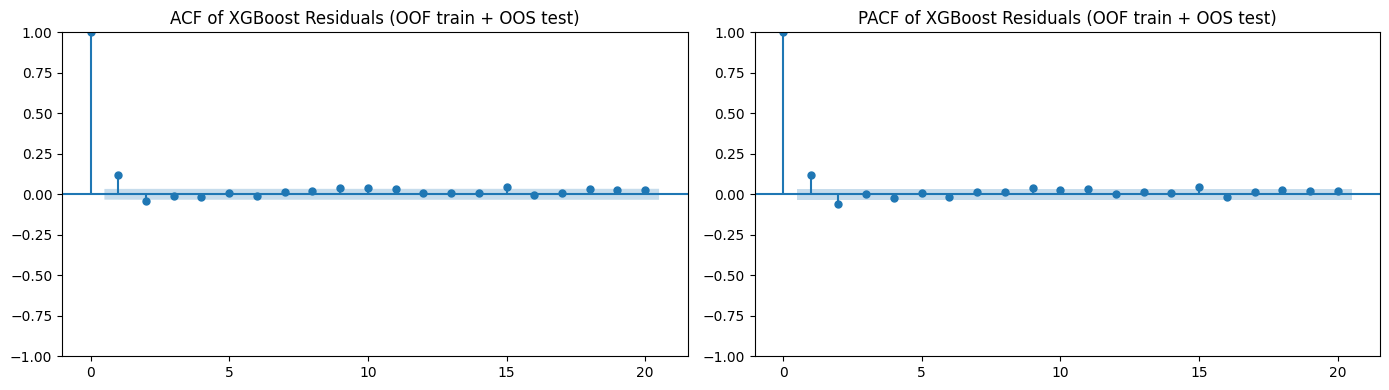

N = 3478 residuals | 95% significance threshold: |ACF| > 0.0332

Lag | ACF value | Significant?
  1 |    0.1170 |  <-- significant
  2 |   -0.0425 |  <-- significant
  3 |   -0.0110 |
  4 |   -0.0197 |
  5 |    0.0055 |
  6 |   -0.0109 |
  7 |    0.0126 |
  8 |    0.0211 |
  9 |    0.0419 |  <-- significant
 10 |    0.0376 |  <-- significant
 11 |    0.0340 |  <-- significant
 12 |    0.0072 |
 13 |    0.0100 |
 14 |    0.0087 |
 15 |    0.0444 |  <-- significant
 16 |   -0.0038 |
 17 |    0.0075 |
 18 |    0.0302 |
 19 |    0.0262 |
 20 |    0.0258 |

Statistically significant lags (95% level): [1, 2, 9, 10, 11, 15]

Ljung-Box test (H0: no autocorrelation up to the given lag):
      lb_stat     lb_pvalue
5   55.826496  8.823323e-11
10  69.389684  5.815016e-11
20  89.284626  9.884496e-11

(A p-value below 0.05 rejects H0 -- i.e. there IS significant autocorrelation up to that lag.)


In [ ]:
# =============================================================================
# RESIDUAL AUTOCORRELATION (ACF / PACF) DIAGNOSTICS
# -----------------------------------------------------------------------------
# WHAT THIS CELL DOES
#   Plots the autocorrelation (ACF) and partial autocorrelation (PACF) of the
#   OOF-train / OOS-test residual series, then flags which lags are
#   statistically significant using the standard large-sample white-noise
#   bound |ACF(k)| > 1.96/sqrt(N), and cross-checks with a Ljung-Box test.
#
# HOW TO READ IT
#   - ACF: correlation between the residual at time t and at time t-k.
#   - PACF: same, but with the effect of the intermediate lags removed --
#     useful for deciding how many lag features are actually independently
#     informative (e.g. if only lag 1 is significant in the PACF, adding a
#     lag-2 feature likely won't help beyond what lag-1 already captures).
#   - Shaded bands in the plots are the approximate 95% confidence interval
#     under the null hypothesis of no autocorrelation.
# =============================================================================

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf as acf_fn
from statsmodels.stats.diagnostic import acorr_ljungbox

# Use only rows with a valid (non-NaN) residual -- excludes Fold 1's
# OOF-uncovered training block (see Section 7).
residual_series = df['Residual'].dropna()
N = len(residual_series)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(residual_series, lags=20, ax=axes[0], alpha=0.05)
axes[0].set_title("ACF of XGBoost Residuals (OOF train + OOS test)")
plot_pacf(residual_series, lags=20, ax=axes[1], alpha=0.05, method='ywm')
axes[1].set_title("PACF of XGBoost Residuals (OOF train + OOS test)")
plt.tight_layout()
plt.show()

# ── Identify statistically significant lags (ACF) ────────────────────────────
n_lags = 20
threshold = 1.959964 / np.sqrt(N)  # standard 95% approx. bound for white noise
acf_vals = acf_fn(residual_series, nlags=n_lags, fft=False)

print(f"N = {N} residuals | 95% significance threshold: |ACF| > {threshold:.4f}\n")
print("Lag | ACF value | Significant?")
significant_lags = []
for lag in range(1, n_lags + 1):
    is_sig = abs(acf_vals[lag]) > threshold
    marker = "  <-- significant" if is_sig else ""
    print(f"{lag:>3} | {acf_vals[lag]:>9.4f} |{marker}")
    if is_sig:
        significant_lags.append(lag)

print(f"\nStatistically significant lags (95% level): {significant_lags}")

# ── Ljung-Box test: are residuals jointly autocorrelated up to lag k? ───────
lb_test = acorr_ljungbox(residual_series, lags=[5, 10, 20], return_df=True)
print("\nLjung-Box test (H0: no autocorrelation up to the given lag):")
print(lb_test)
print("\n(A p-value below 0.05 rejects H0 -- i.e. there IS significant "
      "autocorrelation up to that lag.)")


## 10. LSTM Residual Correction Model -- Data Preparation


In [ ]:
# =============================================================================
# Feature set for LSTM residual correction model
# -----------------------------------------------------------------------------
# Adds two new engineered features: Residual_lag1, Residual_lag2 -- the
# previous 1 and 2 days' OOF (train) / out-of-sample (test) XGBoost
# residuals. The ACF/PACF diagnostics above (Section 9) are used to decide
# whether these lags carry real signal; the features are included here so
# the LSTM can exploit residual autocorrelation that the exogenous features
# alone cannot capture, since the LSTM otherwise sees the same information
# XGBoost already used.
#
# WHY THIS IS NOT LEAKAGE: at forecast time for day t, the actual wind speed
# (and hence residual) for day t-1 and t-2 has already been observed -- these
# are genuine past values, not information from the future or from the row
# being predicted itself.
#
# Train rows: restricted to those with a valid OUT-OF-FOLD residual (see
#   Section 7). The initial training block with no OOF coverage is dropped.
# Test rows: unchanged -- always genuinely out-of-sample.
# =============================================================================

df['Residual_lag1'] = df['Residual'].shift(1)
df['Residual_lag2'] = df['Residual'].shift(2)

# NOTE: df_backup was already snapshotted (df_backup = df.copy()) back in
# Section 8, BEFORE these two lag columns existed on df -- so df_backup is
# missing them unless we sync them across explicitly here. Every downstream
# section reads df_backup (not df) when saving the per-model CSV export via
# `df_backup[fnn_features + [...]]`, which would otherwise raise
# `KeyError: ['Residual_lag1', 'Residual_lag2'] not in index`.
df_backup['Residual_lag1'] = df['Residual_lag1']
df_backup['Residual_lag2'] = df['Residual_lag2']

# RESIDUAL CORRECTION MODEL
fnn_features = [
    'Residual_lag1', 'Residual_lag2'    # NEW: autoregressive residual features
]

X_res = df[fnn_features]  # Features for residual correction
y_res = df['Residual']    # Target: OOF (train) / out-of-sample (test) XGBoost residuals

# Same 80 / 20 temporal split index as the primary model
split_index_res = int(len(X_res) * 0.8)

X_train_res_full = X_res.iloc[:split_index_res]
y_train_res_full = y_res.iloc[:split_index_res]
X_test_res        = X_res.iloc[split_index_res:]
y_test_res         = y_res.iloc[split_index_res:]

# ── Drop rows with any NaN feature or target ─────────────────────────────────
# Two independent sources of NaN now exist:
#   1. Fold 1 of TimeSeriesSplit(n_splits=5) has no preceding validation
#      block, so its training rows were never given an OOF residual
#      (Section 7) -- this affects y_train_res_full AND, via the .shift()
#      above, the Residual_lag1 / Residual_lag2 columns of the rows right
#      after that gap.
#   2. The very first 1-2 rows of the entire series have no lag-1/lag-2
#      residual to look back on.
# Filling either with a synthetic value would fabricate information or
# quietly leak, so these rows are dropped instead. Test rows are expected to
# lose none (their lag features look back into the already-valid tail of the
# training period), but the same check is applied for correctness.
train_valid_mask = X_train_res_full.notna().all(axis=1) & y_train_res_full.notna()
test_valid_mask  = X_test_res.notna().all(axis=1)       & y_test_res.notna()

X_train_res = X_train_res_full.loc[train_valid_mask]
y_train_res = y_train_res_full.loc[train_valid_mask]
X_test_res  = X_test_res.loc[test_valid_mask]
y_test_res  = y_test_res.loc[test_valid_mask]

n_dropped_train = int((~train_valid_mask).sum())
n_dropped_test  = int((~test_valid_mask).sum())

print(f"LSTM residual correction -- training rows dropped (no OOF residual "
      f"and/or lag feature): {n_dropped_train}")
print(f"LSTM residual correction -- training samples used  : {X_train_res.shape[0]}")
print(f"LSTM residual correction -- test samples            : {X_test_res.shape[0]} "
      f"(dropped {n_dropped_test} rows with a missing lag feature)")
print(f"Number of input features                             : {X_train_res.shape[1]}")


LSTM residual correction -- training rows dropped (no OOF residual and/or lag feature): 539
LSTM residual correction -- training samples used  : 2673
LSTM residual correction -- test samples            : 803 (dropped 0 rows with a missing lag feature)
Number of input features                             : 2


## 11. LSTM Residual Correction — Original Model (No Hyperparameter Optimisation)


Epoch 1/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.5162 - val_loss: 0.5356
Epoch 2/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5100 - val_loss: 0.5342
Epoch 3/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5094 - val_loss: 0.5342
Epoch 4/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5093 - val_loss: 0.5343
Epoch 5/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5093 - val_loss: 0.5344
Epoch 6/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5092 - val_loss: 0.5344
Epoch 7/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5092 - val_loss: 0.5345
Epoch 8/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5091 - val_loss: 0.5346
Epoch 9/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5091 - val_loss: 0.5346
Epoch 10/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5090 - val_loss: 0.5346
Epoch 11/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5090 - val_loss: 0.5347
Epoch 12/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.

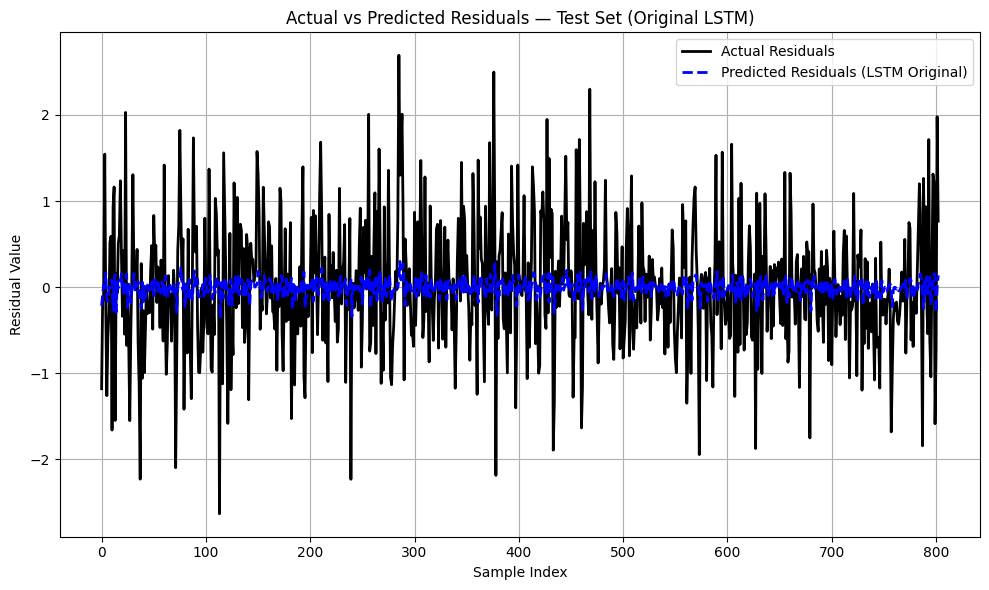

109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Full-dataset residual predictions: 3476 / 4015 rows (NaN elsewhere -- missing lag feature(s))

=== Hybrid XGB-LSTM (Original) Performance on WS10M ===
(Train metrics computed on 2673 rows -- initial OOF-uncovered block excluded)

--- Train Metrics ---
RMSE: 0.7155
MSE:  0.5119
MAE:  0.5466
MAPE: 15.3005%
R²:   0.7969

--- Test Metrics ---
RMSE: 0.7204
MSE:  0.5190
MAE:  0.5439
MAPE: 14.6966%
R²:   0.7848


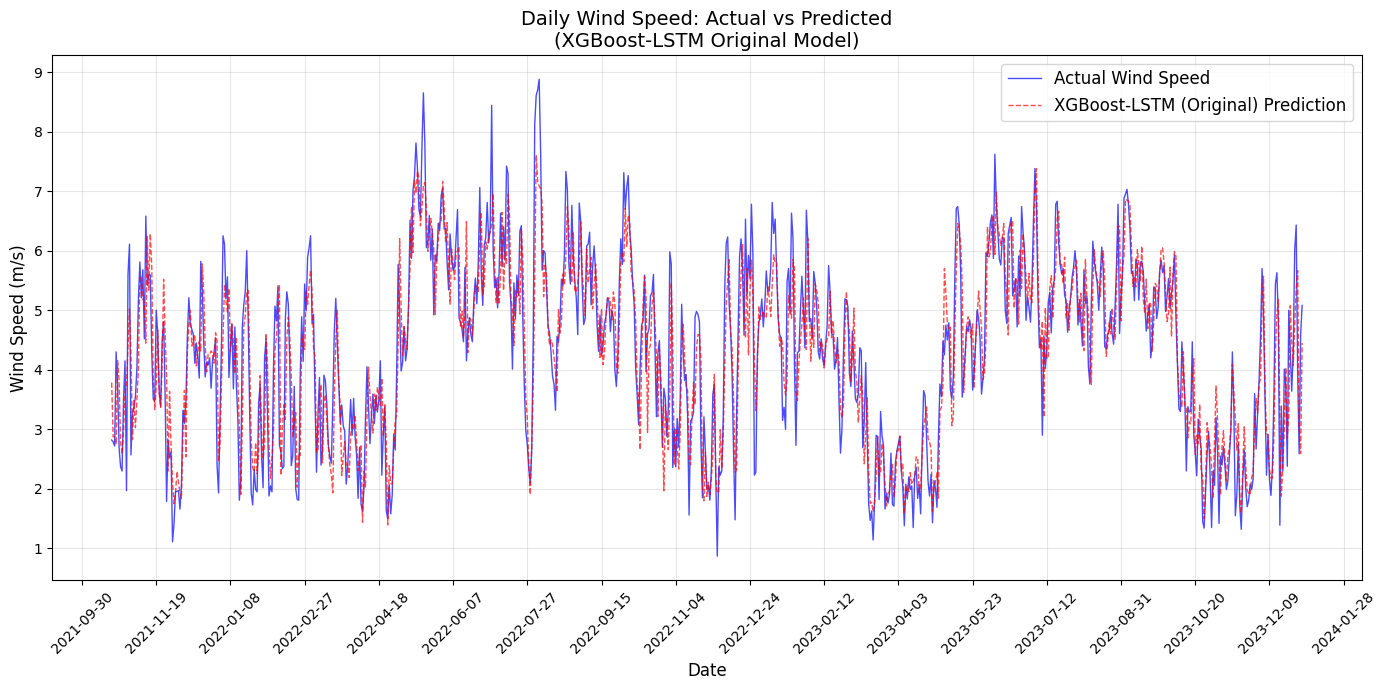

Saved to 'xgb_lstm_df_original.csv'


In [ ]:
# =============================================================================
# Section 1 — Original LSTM model
# Default architecture: single LSTM layer (50 units), no dropout.
# No hyperparameter search is performed in this section.
# Scaling is fit on training data only to prevent data leakage.
# =============================================================================

# ── Scaling (fit on training data only — no leakage) ─────────────────────────
scaler_original     = StandardScaler()
X_train_sc_orig     = scaler_original.fit_transform(X_train_res)
X_test_sc_orig      = scaler_original.transform(X_test_res)

# ── Reshape to LSTM format: (samples, timesteps=1, features) ─────────────────
X_train_lstm_orig   = np.expand_dims(X_train_sc_orig, axis=1)
X_test_lstm_orig    = np.expand_dims(X_test_sc_orig,  axis=1)
y_train_lstm_orig   = y_train_res.values.flatten()
y_test_lstm_orig    = y_test_res.values.flatten()

# ── Build LSTM model ──────────────────────────────────────────────────────────
tf.random.set_seed(RANDOM_SEED)
model_orig = Sequential([
    LSTM(50, activation='tanh',
         input_shape=(X_train_lstm_orig.shape[1], X_train_lstm_orig.shape[2])),
    Dense(1)   # Regression output layer
])
model_orig.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Fit on training residuals only (validation_split takes last 20% of train
# set chronologically — no test-set leakage)
history_orig = model_orig.fit(
    X_train_lstm_orig, y_train_lstm_orig,
    epochs=100,
    batch_size=32,
    validation_split=0.2,  # Uses last 20% of training data as validation
    verbose=1,
    shuffle=False           # Preserve temporal order
)

# ── Residual model evaluation ─────────────────────────────────────────────────
y_train_pred_orig = model_orig.predict(X_train_lstm_orig).flatten()
y_test_pred_orig  = model_orig.predict(X_test_lstm_orig).flatten()

print("\n--- Original LSTM Residual Model Evaluation ---")
evaluate(y_train_lstm_orig, y_train_pred_orig, label="Train (LSTM Original)")
evaluate(y_test_lstm_orig,  y_test_pred_orig,  label="Test  (LSTM Original)")

# Plot residual predictions on test set
plt.figure(figsize=(10, 6))
plt.plot(y_test_lstm_orig, label='Actual Residuals',   color='black', linewidth=2)
plt.plot(y_test_pred_orig, label='Predicted Residuals (LSTM Original)',
         color='blue', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted Residuals — Test Set (Original LSTM)')
plt.xlabel('Sample Index')
plt.ylabel('Residual Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ── Predict residuals on the FULL dataset ────────────────────────────────────
# NOTE: X_res (unlike X_train_res/X_test_res) is NOT pre-filtered for NaNs --
# it still contains the rows Section 10 dropped (Fold 1's OOF-uncovered
# training block, plus the first 1-2 rows with no Residual_lag1/lag2 to look
# back on). The LSTM can't handle NaN input, so we predict only on the rows
# where every feature is valid, and leave the rest as NaN -- consistent with
# 'Pred_XGB_Optuna' already being NaN for those same rows.
full_valid_mask = X_res.notna().all(axis=1)
X_full_sc_valid   = scaler_original.transform(X_res.loc[full_valid_mask])
X_full_lstm_valid = np.expand_dims(X_full_sc_valid, axis=1)

predicted_residuals_lstm_original_arr = np.full(len(X_res), np.nan)
predicted_residuals_lstm_original_arr[full_valid_mask.values] = model_orig.predict(X_full_lstm_valid).flatten()
print(f"Full-dataset residual predictions: {int(full_valid_mask.sum())} / "
      f"{len(X_res)} rows (NaN elsewhere -- missing lag feature(s))")

df_backup['predicted_residuals_lstm_original'] = predicted_residuals_lstm_original_arr

# ── Hybrid prediction: XGB + LSTM residual correction ────────────────────────
df_backup['XGB_LSTM_original'] = (df_backup['Pred_XGB_Optuna'] +
                                   df_backup['predicted_residuals_lstm_original'])

# ── Hybrid model train / test performance ────────────────────────────────────
# NOTE: df_backup['XGB_LSTM_original'] is NaN for the initial training block that has no
# OOF residual (Sections 7 & 9) -- Pred_XGB_Optuna is NaN there, so those
# rows must be dropped before computing metrics, otherwise mean_squared_error
# etc. would raise or silently propagate NaN. Test rows are unaffected (they
# were always out-of-sample).
train_df_orig = df_backup.iloc[:split_index_res].copy()
train_df_orig = train_df_orig.dropna(subset=['XGB_LSTM_original'])
test_df_orig  = df_backup.iloc[split_index_res:].copy()

print("\n=== Hybrid XGB-LSTM (Original) Performance on WS10M ===")
print(f"(Train metrics computed on {len(train_df_orig)} rows -- initial "
      f"OOF-uncovered block excluded)")
train_metrics_orig = evaluate_performance(
    train_df_orig['WS10M'], train_df_orig['XGB_LSTM_original'], set_name="Train")
test_metrics_orig  = evaluate_performance(
    test_df_orig['WS10M'],  test_df_orig['XGB_LSTM_original'],  set_name="Test")

# ── Visualise test-set hybrid predictions ────────────────────────────────────
test_df_orig.index = pd.to_datetime(test_df_orig.index)
plt.figure(figsize=(14, 7))
plt.plot(test_df_orig.index, test_df_orig['WS10M'],
         label='Actual Wind Speed', color='blue', alpha=0.7, linewidth=1)
plt.plot(test_df_orig.index, test_df_orig['XGB_LSTM_original'],
         label='XGBoost-LSTM (Original) Prediction',
         color='red', linestyle='--', alpha=0.7, linewidth=1)
plt.title('Daily Wind Speed: Actual vs Predicted\n(XGBoost-LSTM Original Model)',
          fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Wind Speed (m/s)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(20))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Save results to CSV
xgb_lstm_df_original = df_backup[fnn_features + ['WS10M', 'XGB_LSTM_original']]
xgb_lstm_df_original.to_csv('xgb_lstm_df_original.csv', index=True)
print("Saved to 'xgb_lstm_df_original.csv'")


## 12. LSTM Residual Correction — Grid Search Hyperparameter Optimisation


Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best Parameters (Grid Search):
{'batch_size': 32, 'epochs': 50, 'model__dropout_rate': 0.3, 'model__optimizer': 'rmsprop', 'model__units': 32}

--- Grid Search LSTM Residual Model Evaluation ---
Train (LSTM Grid Search) MSE:  0.5118
Train (LSTM Grid Search) RMSE: 0.7154
Train (LSTM Grid Search) MAE:  0.5474
Train (LSTM Grid Search) MAPE: 163.47%
Train (LSTM Grid Search) R²:   0.0190
Test  (LSTM Grid Search) MSE:  0.5180
Test  (LSTM Grid Search) RMSE: 0.7197
Test  (LSTM Grid Search) MAE:  0.5434
Test  (LSTM Grid Search) MAPE: 143.05%
Test  (LSTM Grid Search) R²:   0.0148


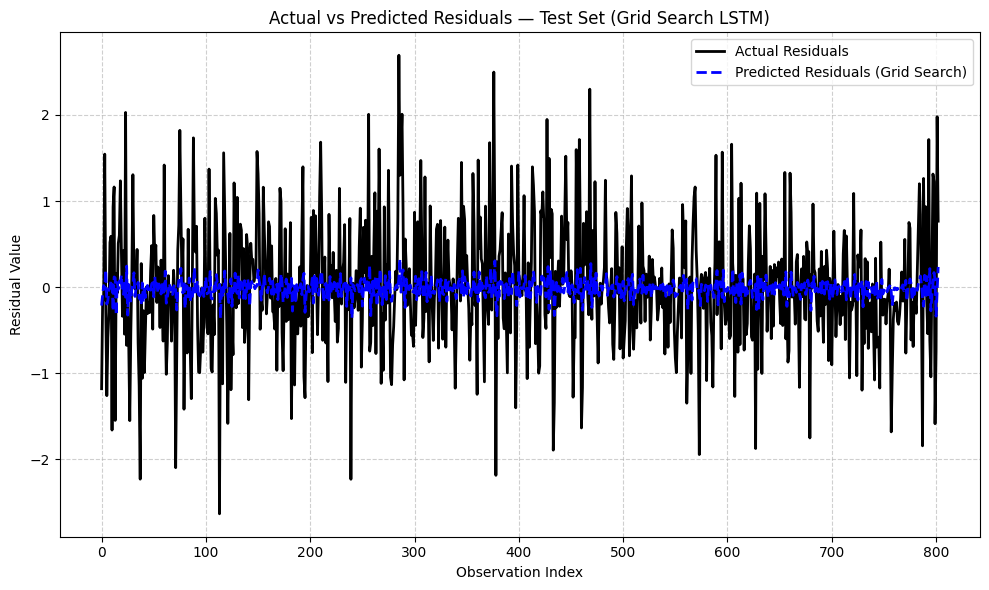

Full-dataset residual predictions: 3476 / 4015 rows (NaN elsewhere -- missing lag feature(s))

=== Hybrid XGB-LSTM (Grid Search) Performance on WS10M ===
(Train metrics computed on 2673 rows -- initial OOF-uncovered block excluded)

--- Train Metrics ---
RMSE: 0.7154
MSE:  0.5118
MAE:  0.5474
MAPE: 15.2854%
R²:   0.7969

--- Test Metrics ---
RMSE: 0.7197
MSE:  0.5180
MAE:  0.5434
MAPE: 14.6395%
R²:   0.7852


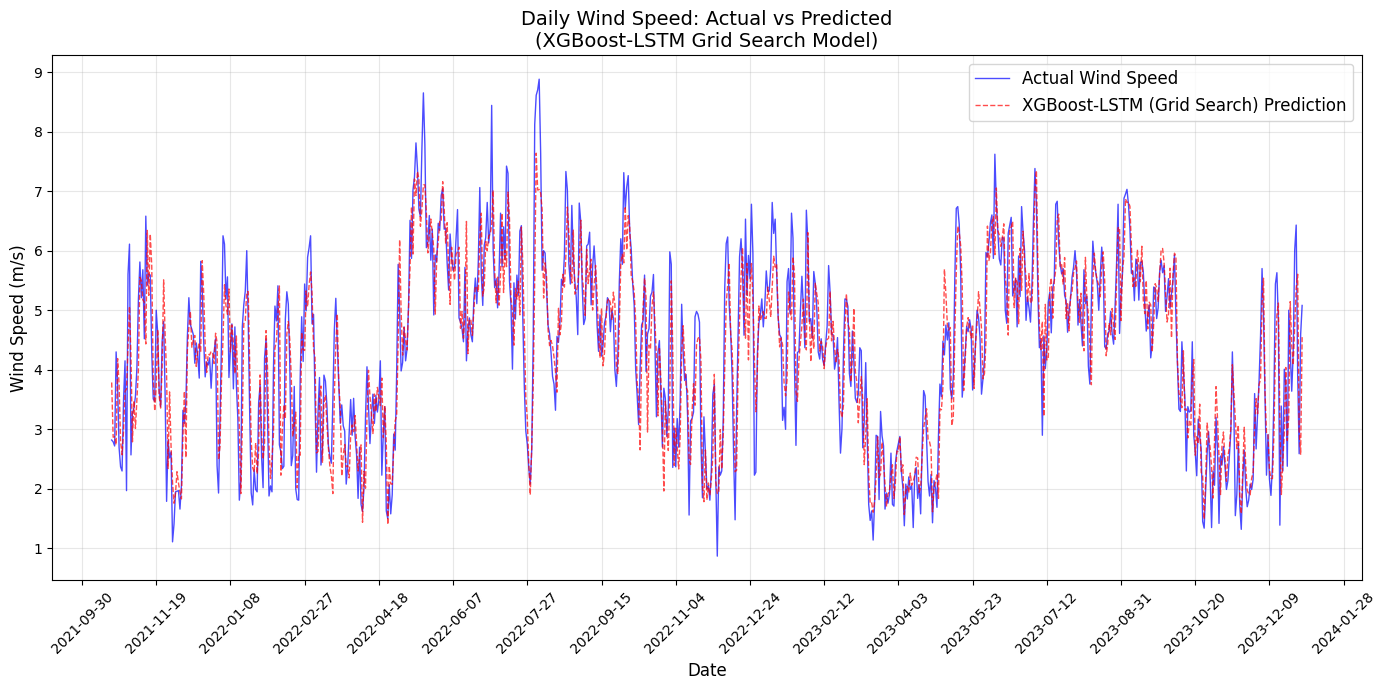

Saved to 'xgb_lstm_df_grid.csv'


In [ ]:
# =============================================================================
# Section 2 — Grid Search LSTM
# Exhaustive grid search over the defined parameter grid.
# TimeSeriesSplit (5 folds) is applied exclusively on the training data.
# Scaling is fit on training data only to prevent data leakage.
#
# FIX vs original code:
#   - Replaced cv=3 (standard K-Fold) with TimeSeriesSplit(n_splits=5)
#     to respect temporal ordering during cross-validation.
#   - Removed mid-notebook CSV reload which would have broken the pipeline
#     and required a separate file to exist on disk.
#   - All data is sourced from in-memory objects (X_train_res, y_train_res).
# =============================================================================

# ── Scaling (fit on training data only — no leakage) ─────────────────────────
scaler_grid     = StandardScaler()
X_train_sc_grid = scaler_grid.fit_transform(X_train_res)
X_test_sc_grid  = scaler_grid.transform(X_test_res)

# ── Reshape to LSTM format: (samples, timesteps=1, features) ─────────────────
X_train_lstm_grid = np.expand_dims(X_train_sc_grid, axis=1)
X_test_lstm_grid  = np.expand_dims(X_test_sc_grid,  axis=1)

# ── LSTM model builder (required by KerasRegressor) ──────────────────────────
def build_lstm_grid(units=64, dropout_rate=0.2, optimizer='adam'):
    """Builds and compiles an LSTM model for use in GridSearchCV."""
    n_features = X_train_lstm_grid.shape[2]
    mdl = Sequential([
        LSTM(units, activation='tanh', return_sequences=False,
             input_shape=(1, n_features)),
        Dropout(dropout_rate),
        Dense(1)
    ])
    mdl.compile(optimizer=optimizer, loss='mse')
    return mdl

# ── Wrap Keras model for scikit-learn API ─────────────────────────────────────
regressor_grid = KerasRegressor(
    model=build_lstm_grid, verbose=0, random_state=RANDOM_SEED
)

# ── Parameter grid ────────────────────────────────────────────────────────────
param_grid = {
    "model__units":        [32, 64, 128],
    "model__dropout_rate": [0.1, 0.2, 0.3],
    "model__optimizer":    ['adam', 'rmsprop'],
    "batch_size":          [16, 32],
    "epochs":              [50, 100]
}

# ── Time series cross-validation (training data only) ────────────────────────
tscv_grid = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=regressor_grid,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=tscv_grid,           # TimeSeriesSplit preserves temporal ordering
    verbose=2,
    n_jobs=-1
)

# Fit grid search on training data only
grid_search.fit(X_train_lstm_grid, y_train_res.values.flatten())

best_model_grid = grid_search.best_estimator_
print("\nBest Parameters (Grid Search):")
print(grid_search.best_params_)

# ── Residual model evaluation ─────────────────────────────────────────────────
y_train_pred_grid = best_model_grid.predict(X_train_lstm_grid).flatten()
y_test_pred_grid  = best_model_grid.predict(X_test_lstm_grid).flatten()

print("\n--- Grid Search LSTM Residual Model Evaluation ---")
evaluate(y_train_res.values, y_train_pred_grid, label="Train (LSTM Grid Search)")
evaluate(y_test_res.values,  y_test_pred_grid,  label="Test  (LSTM Grid Search)")

# Plot residual predictions on test set
plt.figure(figsize=(10, 6))
plt.plot(y_test_res.values, label='Actual Residuals',   color='black', linewidth=2)
plt.plot(y_test_pred_grid,  label='Predicted Residuals (Grid Search)',
         color='blue', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted Residuals — Test Set (Grid Search LSTM)')
plt.xlabel('Observation Index')
plt.ylabel('Residual Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ── Predict residuals on the FULL dataset ────────────────────────────────────
# NOTE: X_res (unlike X_train_res/X_test_res) is NOT pre-filtered for NaNs --
# it still contains the rows Section 10 dropped (Fold 1's OOF-uncovered
# training block, plus the first 1-2 rows with no Residual_lag1/lag2 to look
# back on). The LSTM can't handle NaN input, so we predict only on the rows
# where every feature is valid, and leave the rest as NaN -- consistent with
# 'Pred_XGB_Optuna' already being NaN for those same rows.
full_valid_mask = X_res.notna().all(axis=1)
X_full_sc_valid   = scaler_grid.transform(X_res.loc[full_valid_mask])
X_full_lstm_valid = np.expand_dims(X_full_sc_valid, axis=1)

predicted_residuals_lstm_grid_arr = np.full(len(X_res), np.nan)
predicted_residuals_lstm_grid_arr[full_valid_mask.values] = best_model_grid.predict(X_full_lstm_valid).flatten()
print(f"Full-dataset residual predictions: {int(full_valid_mask.sum())} / "
      f"{len(X_res)} rows (NaN elsewhere -- missing lag feature(s))")

df_backup['predicted_residuals_lstm_grid'] = predicted_residuals_lstm_grid_arr

# ── Hybrid prediction: XGB + LSTM residual correction ────────────────────────
df_backup['XGB_LSTM_grid'] = (df_backup['Pred_XGB_Optuna'] +
                               df_backup['predicted_residuals_lstm_grid'])

# ── Hybrid model train / test performance ────────────────────────────────────
# NOTE: df_backup['XGB_LSTM_grid'] is NaN for the initial training block that has no
# OOF residual (Sections 7 & 9) -- Pred_XGB_Optuna is NaN there, so those
# rows must be dropped before computing metrics, otherwise mean_squared_error
# etc. would raise or silently propagate NaN. Test rows are unaffected (they
# were always out-of-sample).
train_df_grid = df_backup.iloc[:split_index_res].copy()
train_df_grid = train_df_grid.dropna(subset=['XGB_LSTM_grid'])
test_df_grid  = df_backup.iloc[split_index_res:].copy()

print("\n=== Hybrid XGB-LSTM (Grid Search) Performance on WS10M ===")
print(f"(Train metrics computed on {len(train_df_grid)} rows -- initial "
      f"OOF-uncovered block excluded)")
train_metrics_grid = evaluate_performance(
    train_df_grid['WS10M'], train_df_grid['XGB_LSTM_grid'], set_name="Train")
test_metrics_grid  = evaluate_performance(
    test_df_grid['WS10M'],  test_df_grid['XGB_LSTM_grid'],  set_name="Test")

# ── Visualise test-set hybrid predictions ────────────────────────────────────
test_df_grid.index = pd.to_datetime(test_df_grid.index)
plt.figure(figsize=(14, 7))
plt.plot(test_df_grid.index, test_df_grid['WS10M'],
         label='Actual Wind Speed', color='blue', alpha=0.7, linewidth=1)
plt.plot(test_df_grid.index, test_df_grid['XGB_LSTM_grid'],
         label='XGBoost-LSTM (Grid Search) Prediction',
         color='red', linestyle='--', alpha=0.7, linewidth=1)
plt.title('Daily Wind Speed: Actual vs Predicted\n(XGBoost-LSTM Grid Search Model)',
          fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Wind Speed (m/s)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(20))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Save results to CSV
xgb_lstm_df_grid = df_backup[fnn_features + ['WS10M', 'XGB_LSTM_grid']]
xgb_lstm_df_grid.to_csv('xgb_lstm_df_grid.csv', index=True)
print("Saved to 'xgb_lstm_df_grid.csv'")


## 13. LSTM Residual Correction — Randomized Search Hyperparameter Optimisation


Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END batch_size=54, epochs=101, model__dropout_rate=0.38521429192297485, model__learning_rate=0.006687945476302646, model__units=40; total time=   9.4s
[CV] END batch_size=54, epochs=101, model__dropout_rate=0.38521429192297485, model__learning_rate=0.006687945476302646, model__units=40; total time=  10.0s
[CV] END batch_size=54, epochs=101, model__dropout_rate=0.38521429192297485, model__learning_rate=0.006687945476302646, model__units=40; total time=  12.8s
[CV] END batch_size=54, epochs=101, model__dropout_rate=0.38521429192297485, model__learning_rate=0.006687945476302646, model__units=40; total time=  15.9s
[CV] END batch_size=54, epochs=101, model__dropout_rate=0.38521429192297485, model__learning_rate=0.006687945476302646, model__units=40; total time=  16.9s
[CV] END batch_size=54, epochs=132, model__dropout_rate=0.12999247474540088, model__learning_rate=0.004233240027692805, model__units=136; total time=  12.7s
[C

[CV] END batch_size=59, epochs=79, model__dropout_rate=0.16370173320348286, model__learning_rate=0.0017364247048639054, model__units=40; total time=   8.0s


[CV] END batch_size=59, epochs=79, model__dropout_rate=0.16370173320348286, model__learning_rate=0.0017364247048639054, model__units=40; total time=  10.4s
[CV] END batch_size=59, epochs=79, model__dropout_rate=0.16370173320348286, model__learning_rate=0.0017364247048639054, model__units=40; total time=  13.1s
[CV] END batch_size=59, epochs=79, model__dropout_rate=0.16370173320348286, model__learning_rate=0.0017364247048639054, model__units=40; total time=  16.2s
[CV] END batch_size=48, epochs=125, model__dropout_rate=0.28349594814648427, model__learning_rate=0.00016359674697745665, model__units=108; total time=  11.9s
[CV] END batch_size=48, epochs=125, model__dropout_rate=0.28349594814648427, model__learning_rate=0.00016359674697745665, model__units=108; total time=  16.8s
[CV] END batch_size=48, epochs=125, model__dropout_rate=0.28349594814648427, model__learning_rate=0.00016359674697745665, model__units=108; total time=  19.9s
[CV] END batch_size=48, epochs=125, model__dropout_rate

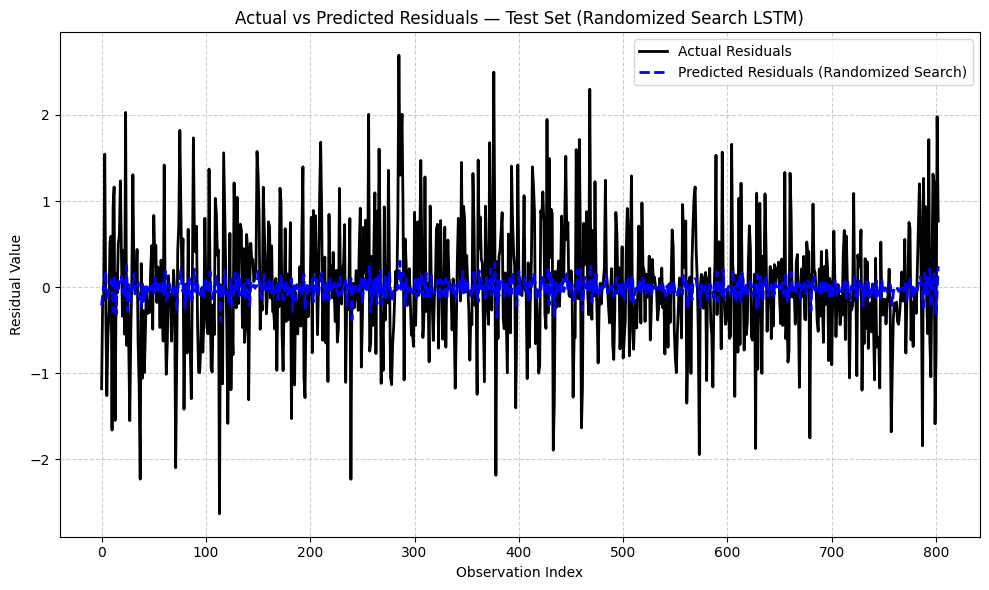

Full-dataset residual predictions: 3476 / 4015 rows (NaN elsewhere -- missing lag feature(s))

=== Hybrid XGB-LSTM (Randomized Search) Performance on WS10M ===
(Train metrics computed on 2673 rows -- initial OOF-uncovered block excluded)

--- Train Metrics ---
RMSE: 0.7156
MSE:  0.5120
MAE:  0.5472
MAPE: 15.2846%
R²:   0.7968

--- Test Metrics ---
RMSE: 0.7202
MSE:  0.5187
MAE:  0.5437
MAPE: 14.6566%
R²:   0.7849


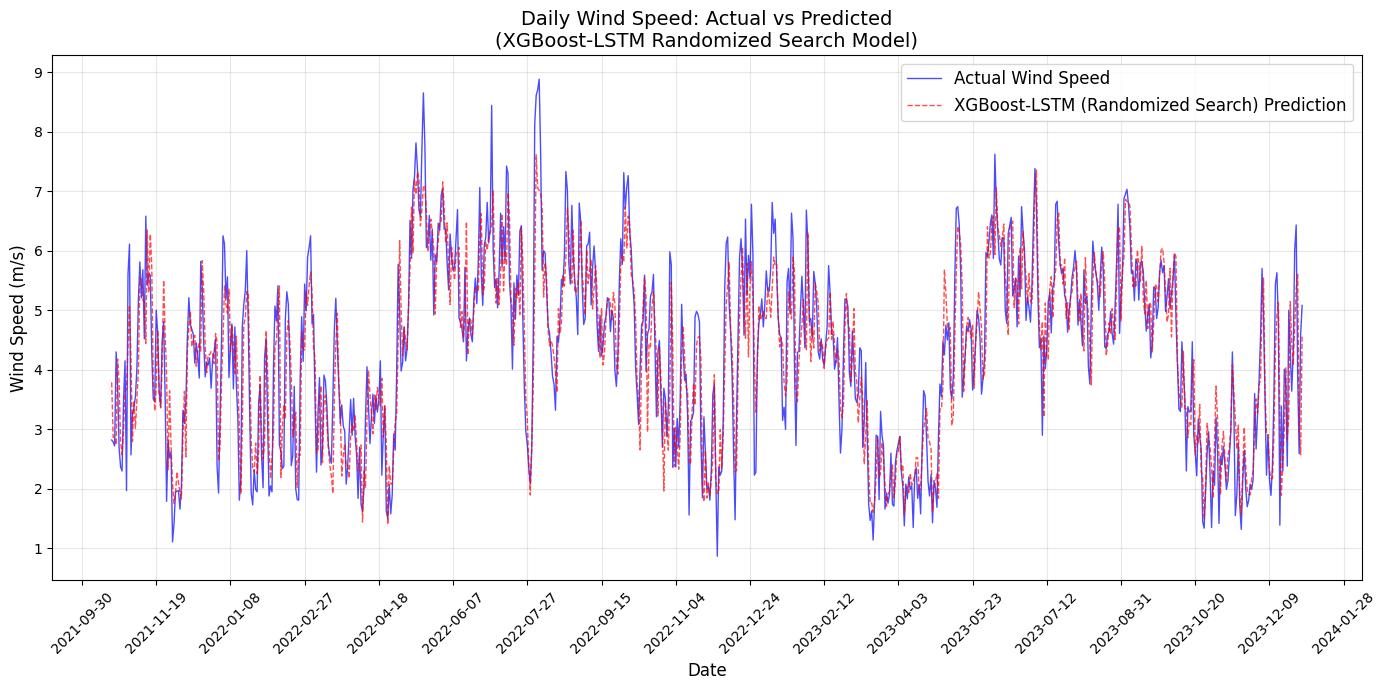

Saved to 'xgb_lstm_df_random.csv'


In [ ]:
# =============================================================================
# Section 3 — Randomized Search LSTM
# Random sampling over hyperparameter distributions (10 iterations).
# TimeSeriesSplit (5 folds) is applied exclusively on training data.
# Scaling is fit on training data only to prevent data leakage.
# =============================================================================

# ── Scaling (fit on training data only — no leakage) ─────────────────────────
scaler_random     = StandardScaler()
X_train_sc_rand   = scaler_random.fit_transform(X_train_res)
X_test_sc_rand    = scaler_random.transform(X_test_res)

# ── Reshape to LSTM format: (samples, timesteps=1, features) ─────────────────
X_train_lstm_rand = np.expand_dims(X_train_sc_rand, axis=1)
X_test_lstm_rand  = np.expand_dims(X_test_sc_rand,  axis=1)

# ── LSTM model builder (required by KerasRegressor) ──────────────────────────
def create_lstm_random(units=50, dropout_rate=0.2, learning_rate=0.001):
    """Builds and compiles an LSTM model for use in RandomizedSearchCV."""
    n_features = X_train_lstm_rand.shape[2]
    mdl = Sequential([
        LSTM(units=units, input_shape=(1, n_features)),
        Dropout(dropout_rate),
        Dense(1)   # Regression output
    ])
    mdl.compile(loss='mse', optimizer=Adam(learning_rate=learning_rate))
    return mdl

# ── Wrap Keras model for scikit-learn API ─────────────────────────────────────
lstm_regressor_rand = KerasRegressor(
    model=create_lstm_random, verbose=0, random_state=RANDOM_SEED
)

# ── Hyperparameter distributions ─────────────────────────────────────────────
param_dist = {
    'model__units':         randint(20, 151),
    'model__dropout_rate':  uniform(0.1, 0.3),
    'model__learning_rate': uniform(1e-4, 9e-3),
    'batch_size':           randint(16, 65),
    'epochs':               randint(50, 151)
}

# ── Time series cross-validation (training data only) ────────────────────────
tscv_rand = TimeSeriesSplit(n_splits=5)

random_search = RandomizedSearchCV(
    estimator=lstm_regressor_rand,
    param_distributions=param_dist,
    n_iter=10,
    scoring='neg_mean_squared_error',
    cv=tscv_rand,           # TimeSeriesSplit preserves temporal ordering
    random_state=RANDOM_SEED,
    verbose=2,
    n_jobs=1                # Sequential to avoid TF/Keras multiprocessing issues
)

# Fit randomized search on training data only
random_search.fit(X_train_lstm_rand, y_train_res.values.flatten())

best_model_rand = random_search.best_estimator_
print("\nBest Parameters (Randomized Search):")
print(random_search.best_params_)

# ── Residual model evaluation ─────────────────────────────────────────────────
y_train_pred_rand = best_model_rand.predict(X_train_lstm_rand).flatten()
y_test_pred_rand  = best_model_rand.predict(X_test_lstm_rand).flatten()

print("\n--- Randomized Search LSTM Residual Model Evaluation ---")
evaluate(y_train_res.values, y_train_pred_rand, label="Train (LSTM Randomized Search)")
evaluate(y_test_res.values,  y_test_pred_rand,  label="Test  (LSTM Randomized Search)")

# Plot residual predictions on test set
plt.figure(figsize=(10, 6))
plt.plot(y_test_res.values, label='Actual Residuals',   color='black', linewidth=2)
plt.plot(y_test_pred_rand,  label='Predicted Residuals (Randomized Search)',
         color='blue', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted Residuals — Test Set (Randomized Search LSTM)')
plt.xlabel('Observation Index')
plt.ylabel('Residual Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ── Predict residuals on the FULL dataset ────────────────────────────────────
# NOTE: X_res (unlike X_train_res/X_test_res) is NOT pre-filtered for NaNs --
# it still contains the rows Section 10 dropped (Fold 1's OOF-uncovered
# training block, plus the first 1-2 rows with no Residual_lag1/lag2 to look
# back on). The LSTM can't handle NaN input, so we predict only on the rows
# where every feature is valid, and leave the rest as NaN -- consistent with
# 'Pred_XGB_Optuna' already being NaN for those same rows.
full_valid_mask = X_res.notna().all(axis=1)
X_full_sc_valid   = scaler_random.transform(X_res.loc[full_valid_mask])
X_full_lstm_valid = np.expand_dims(X_full_sc_valid, axis=1)

predicted_residuals_lstm_random_arr = np.full(len(X_res), np.nan)
predicted_residuals_lstm_random_arr[full_valid_mask.values] = best_model_rand.predict(X_full_lstm_valid).flatten()
print(f"Full-dataset residual predictions: {int(full_valid_mask.sum())} / "
      f"{len(X_res)} rows (NaN elsewhere -- missing lag feature(s))")

df_backup['predicted_residuals_lstm_random'] = predicted_residuals_lstm_random_arr

# ── Hybrid prediction: XGB + LSTM residual correction ────────────────────────
df_backup['XGB_LSTM_random'] = (df_backup['Pred_XGB_Optuna'] +
                                 df_backup['predicted_residuals_lstm_random'])

# ── Hybrid model train / test performance ────────────────────────────────────
# NOTE: df_backup['XGB_LSTM_random'] is NaN for the initial training block that has no
# OOF residual (Sections 7 & 9) -- Pred_XGB_Optuna is NaN there, so those
# rows must be dropped before computing metrics, otherwise mean_squared_error
# etc. would raise or silently propagate NaN. Test rows are unaffected (they
# were always out-of-sample).
train_df_rand = df_backup.iloc[:split_index_res].copy()
train_df_rand = train_df_rand.dropna(subset=['XGB_LSTM_random'])
test_df_rand  = df_backup.iloc[split_index_res:].copy()

print("\n=== Hybrid XGB-LSTM (Randomized Search) Performance on WS10M ===")
print(f"(Train metrics computed on {len(train_df_rand)} rows -- initial "
      f"OOF-uncovered block excluded)")
train_metrics_rand = evaluate_performance(
    train_df_rand['WS10M'], train_df_rand['XGB_LSTM_random'], set_name="Train")
test_metrics_rand  = evaluate_performance(
    test_df_rand['WS10M'],  test_df_rand['XGB_LSTM_random'],  set_name="Test")

# ── Visualise test-set hybrid predictions ────────────────────────────────────
test_df_rand.index = pd.to_datetime(test_df_rand.index)
plt.figure(figsize=(14, 7))
plt.plot(test_df_rand.index, test_df_rand['WS10M'],
         label='Actual Wind Speed', color='blue', alpha=0.7, linewidth=1)
plt.plot(test_df_rand.index, test_df_rand['XGB_LSTM_random'],
         label='XGBoost-LSTM (Randomized Search) Prediction',
         color='red', linestyle='--', alpha=0.7, linewidth=1)
plt.title('Daily Wind Speed: Actual vs Predicted\n(XGBoost-LSTM Randomized Search Model)',
          fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Wind Speed (m/s)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(20))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Save results to CSV
xgb_lstm_df_random = df_backup[fnn_features + ['WS10M', 'XGB_LSTM_random']]
xgb_lstm_df_random.to_csv('xgb_lstm_df_random.csv', index=True)
print("Saved to 'xgb_lstm_df_random.csv'")


## 14. LSTM Residual Correction — Optuna Bayesian Optimisation



Best Trial:
FrozenTrial(number=5, state=<TrialState.COMPLETE: 1>, values=[0.5295991742570767], datetime_start=datetime.datetime(2026, 8, 2, 5, 19, 30, 193426), datetime_complete=datetime.datetime(2026, 8, 2, 5, 22, 24, 948320), params={'units': 125, 'dropout_rate': 0.2218455076693483, 'learning_rate': 0.0001567993391672301, 'batch_size': 16, 'epochs': 100}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'units': IntDistribution(high=150, log=False, low=20, step=1), 'dropout_rate': FloatDistribution(high=0.5, log=False, low=0.1, step=None), 'learning_rate': FloatDistribution(high=0.01, log=True, low=0.0001, step=None), 'batch_size': CategoricalDistribution(choices=(16, 32, 64)), 'epochs': IntDistribution(high=150, log=False, low=50, step=1)}, trial_id=5, value=None)

Best Parameters (Optuna):
{'units': 125, 'dropout_rate': 0.2218455076693483, 'learning_rate': 0.0001567993391672301, 'batch_size': 16, 'epochs': 100}
Epoch 1/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/

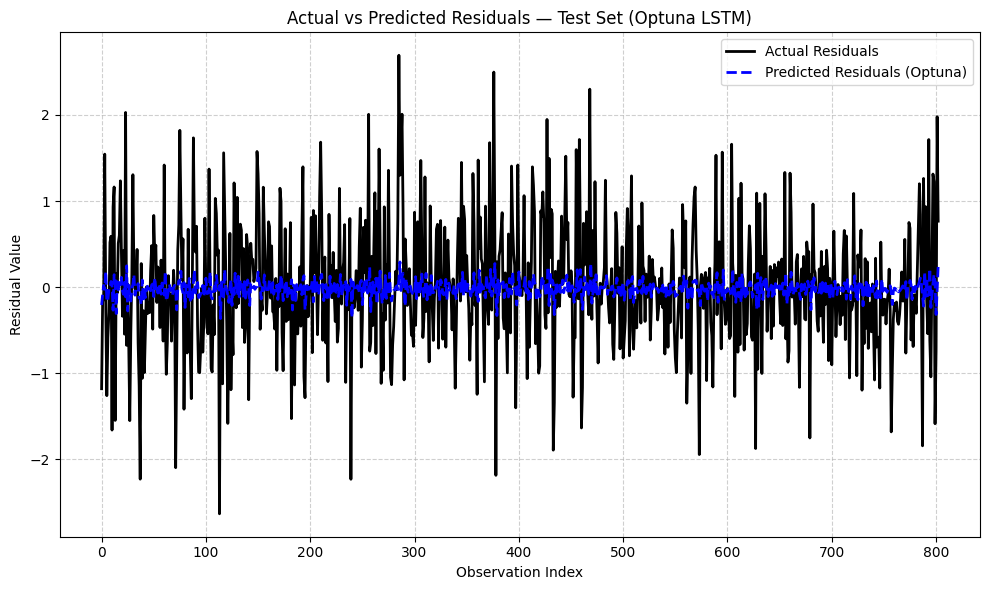

109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Full-dataset residual predictions: 3476 / 4015 rows (NaN elsewhere -- missing lag feature(s))

=== Hybrid XGB-LSTM (Optuna) Performance on WS10M ===
(Train metrics computed on 2673 rows -- initial OOF-uncovered block excluded)

--- Train Metrics ---
RMSE: 0.7156
MSE:  0.5121
MAE:  0.5475
MAPE: 15.2723%
R²:   0.7968

--- Test Metrics ---
RMSE: 0.7202
MSE:  0.5187
MAE:  0.5435
MAPE: 14.6260%
R²:   0.7849


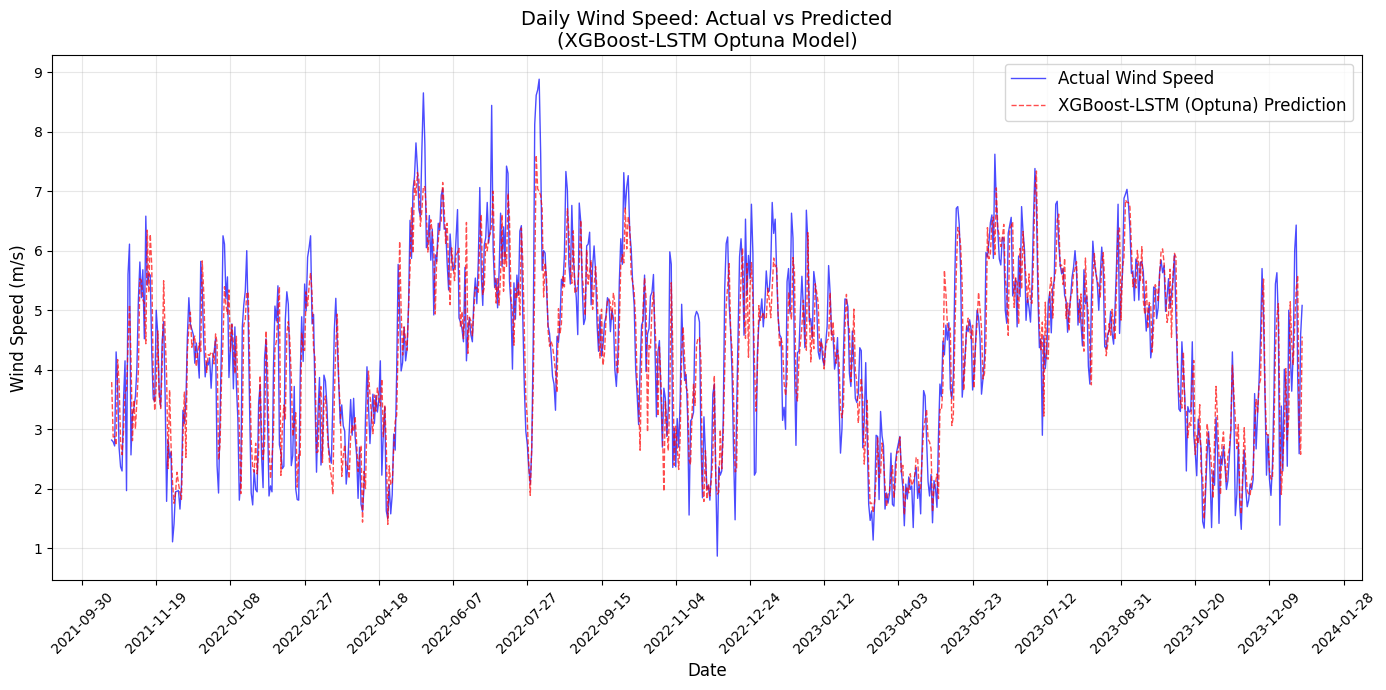

Saved to 'xgb_lstm_df_optuna.csv'


In [ ]:
# =============================================================================
# Section 4 — Optuna LSTM
# Bayesian (TPE) hyperparameter search over architecture and training params.
# TimeSeriesSplit (5 folds) is applied exclusively on training data.
# Scaling is fit on training data only to prevent data leakage.
#
# FIXES vs original code:
#   1. suggest_loguniform() is DEPRECATED in Optuna ≥ 3.x.
#      Replaced with suggest_float('learning_rate', ..., log=True).
#   2. The original code built the LSTM model ONCE in create_lstm_model()
#      and called model.fit() multiple times within the CV loop — this
#      accumulates gradients across folds (weight leakage between folds).
#      Fixed: the model is rebuilt fresh for every fold inside the objective.
#   3. Pre-scaled numpy array (X_train_sc_opt) is used throughout the
#      objective to ensure the LSTM sees the same scaled input as the
#      final model fitted after the study.
# =============================================================================

# ── Scaling (fit on training data only — no leakage) ─────────────────────────
scaler_optuna     = StandardScaler()
X_train_sc_opt    = scaler_optuna.fit_transform(X_train_res)
X_test_sc_opt     = scaler_optuna.transform(X_test_res)

# ── Reshape to LSTM format: (samples, timesteps=1, features) ─────────────────
X_train_lstm_opt  = np.expand_dims(X_train_sc_opt, axis=1)
X_test_lstm_opt   = np.expand_dims(X_test_sc_opt,  axis=1)
n_features_opt    = X_train_lstm_opt.shape[2]

# ── Optuna objective function ─────────────────────────────────────────────────
def lstm_objective(trial):
    """
    Objective for Optuna Bayesian optimisation.
    A FRESH model is rebuilt for every cross-validation fold to prevent
    gradient / weight accumulation across folds (data leakage).
    """
    units         = trial.suggest_int('units', 20, 150)
    dropout_rate  = trial.suggest_float('dropout_rate', 0.1, 0.5)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    batch_size    = trial.suggest_categorical('batch_size', [16, 32, 64])
    epochs        = trial.suggest_int('epochs', 50, 150)

    tscv       = TimeSeriesSplit(n_splits=5)
    mse_scores = []

    for train_idx, val_idx in tscv.split(X_train_lstm_opt):
        # Use pre-scaled numpy slices (no double-scaling / leakage)
        X_t = X_train_lstm_opt[train_idx]
        X_v = X_train_lstm_opt[val_idx]
        y_t = y_train_res.values[train_idx]
        y_v = y_train_res.values[val_idx]

        # Build a FRESH model for each fold to prevent weight accumulation
        tf.random.set_seed(RANDOM_SEED)
        fold_model = Sequential([
            LSTM(units=units, input_shape=(1, n_features_opt)),
            Dropout(dropout_rate),
            Dense(1)
        ])
        fold_model.compile(loss='mse',
                           optimizer=Adam(learning_rate=learning_rate))
        fold_model.fit(X_t, y_t, epochs=epochs, batch_size=batch_size,
                       verbose=0, shuffle=False)

        preds = fold_model.predict(X_v, verbose=0).flatten()
        mse_scores.append(mean_squared_error(y_v, preds))

    return np.mean(mse_scores)

# ── Create and run Optuna study ───────────────────────────────────────────────
study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED)
)
# Max 30 trials or 10 minutes, whichever comes first
study.optimize(lstm_objective, n_trials=30, timeout=600)

print("\nBest Trial:")
print(study.best_trial)
print("\nBest Parameters (Optuna):")
print(study.best_params)

# ── Refit final model on full training data with best parameters ─────────────
best_params_opt = study.best_params

tf.random.set_seed(RANDOM_SEED)
final_model_opt = Sequential([
    LSTM(units=best_params_opt['units'], input_shape=(1, n_features_opt)),
    Dropout(best_params_opt['dropout_rate']),
    Dense(1)
])
final_model_opt.compile(
    loss='mse',
    optimizer=Adam(learning_rate=best_params_opt['learning_rate'])
)
final_model_opt.fit(
    X_train_lstm_opt, y_train_res.values.flatten(),
    epochs=best_params_opt['epochs'],
    batch_size=best_params_opt['batch_size'],
    verbose=1,
    shuffle=False   # Preserve temporal order
)

# ── Residual model evaluation ─────────────────────────────────────────────────
y_train_pred_opt = final_model_opt.predict(X_train_lstm_opt).flatten()
y_test_pred_opt  = final_model_opt.predict(X_test_lstm_opt).flatten()

print("\n--- Optuna LSTM Residual Model Evaluation ---")
evaluate(y_train_res.values, y_train_pred_opt, label="Train (LSTM Optuna)")
evaluate(y_test_res.values,  y_test_pred_opt,  label="Test  (LSTM Optuna)")

# Plot residual predictions on test set
plt.figure(figsize=(10, 6))
plt.plot(y_test_res.values, label='Actual Residuals', color='black', linewidth=2)
plt.plot(y_test_pred_opt,   label='Predicted Residuals (Optuna)',
         color='blue', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted Residuals — Test Set (Optuna LSTM)')
plt.xlabel('Observation Index')
plt.ylabel('Residual Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ── Predict residuals on the FULL dataset ────────────────────────────────────
# NOTE: X_res (unlike X_train_res/X_test_res) is NOT pre-filtered for NaNs --
# it still contains the rows Section 10 dropped (Fold 1's OOF-uncovered
# training block, plus the first 1-2 rows with no Residual_lag1/lag2 to look
# back on). The LSTM can't handle NaN input, so we predict only on the rows
# where every feature is valid, and leave the rest as NaN -- consistent with
# 'Pred_XGB_Optuna' already being NaN for those same rows.
full_valid_mask = X_res.notna().all(axis=1)
X_full_sc_valid   = scaler_optuna.transform(X_res.loc[full_valid_mask])
X_full_lstm_valid = np.expand_dims(X_full_sc_valid, axis=1)

predicted_residuals_lstm_optuna_arr = np.full(len(X_res), np.nan)
predicted_residuals_lstm_optuna_arr[full_valid_mask.values] = final_model_opt.predict(X_full_lstm_valid).flatten()
print(f"Full-dataset residual predictions: {int(full_valid_mask.sum())} / "
      f"{len(X_res)} rows (NaN elsewhere -- missing lag feature(s))")

df_backup['predicted_residuals_lstm_optuna'] = predicted_residuals_lstm_optuna_arr

# ── Hybrid prediction: XGB + LSTM residual correction ────────────────────────
df_backup['XGB_LSTM_optuna'] = (df_backup['Pred_XGB_Optuna'] +
                                 df_backup['predicted_residuals_lstm_optuna'])

# ── Hybrid model train / test performance ────────────────────────────────────
# NOTE: df_backup['XGB_LSTM_optuna'] is NaN for the initial training block that has no
# OOF residual (Sections 7 & 9) -- Pred_XGB_Optuna is NaN there, so those
# rows must be dropped before computing metrics, otherwise mean_squared_error
# etc. would raise or silently propagate NaN. Test rows are unaffected (they
# were always out-of-sample).
train_df_opt = df_backup.iloc[:split_index_res].copy()
train_df_opt = train_df_opt.dropna(subset=['XGB_LSTM_optuna'])
test_df_opt  = df_backup.iloc[split_index_res:].copy()

print("\n=== Hybrid XGB-LSTM (Optuna) Performance on WS10M ===")
print(f"(Train metrics computed on {len(train_df_opt)} rows -- initial "
      f"OOF-uncovered block excluded)")
train_metrics_opt = evaluate_performance(
    train_df_opt['WS10M'], train_df_opt['XGB_LSTM_optuna'], set_name="Train")
test_metrics_opt  = evaluate_performance(
    test_df_opt['WS10M'],  test_df_opt['XGB_LSTM_optuna'],  set_name="Test")

# ── Visualise test-set hybrid predictions ────────────────────────────────────
test_df_opt.index = pd.to_datetime(test_df_opt.index)
plt.figure(figsize=(14, 7))
plt.plot(test_df_opt.index, test_df_opt['WS10M'],
         label='Actual Wind Speed', color='blue', alpha=0.7, linewidth=1)
plt.plot(test_df_opt.index, test_df_opt['XGB_LSTM_optuna'],
         label='XGBoost-LSTM (Optuna) Prediction',
         color='red', linestyle='--', alpha=0.7, linewidth=1)
plt.title('Daily Wind Speed: Actual vs Predicted\n(XGBoost-LSTM Optuna Model)',
          fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Wind Speed (m/s)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(20))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Save results to CSV
xgb_lstm_df_optuna = df_backup[fnn_features + ['WS10M', 'XGB_LSTM_optuna']]
xgb_lstm_df_optuna.to_csv('xgb_lstm_df_optuna.csv', index=True)
print("Saved to 'xgb_lstm_df_optuna.csv'")


## 15. Comprehensive Performance Comparison Across All Methods


In [ ]:
# =============================================================================
# Summary comparison of all four XGBoost-LSTM hybrid model variants.
# Method labels: "Original Model", "Grid Search", "Randomized Search", "Optuna"
# =============================================================================

actual = df_backup['WS10M']

# Map human-readable method names to dataframe column names
methods_map = {
    'Original Model':    'XGB_LSTM_original',
    'Grid Search':       'XGB_LSTM_grid',
    'Randomized Search': 'XGB_LSTM_random',
    'Optuna':            'XGB_LSTM_optuna'
}

split_idx    = int(0.8 * len(df_backup))
train_actual = actual.iloc[:split_idx]
test_actual  = actual.iloc[split_idx:]

# NOTE: the initial training block has no OOF residual (Sections 7 & 9), so
# every 'XGB_LSTM_*' column is NaN there. Those rows are dropped per-method
# before computing metrics -- otherwise mean_squared_error etc. would raise
# or silently propagate NaN into the comparison table. Test rows are
# unaffected (they were always out-of-sample).
results = []
for method_name, col_name in methods_map.items():
    pred       = df_backup[col_name]
    train_pred = pred.iloc[:split_idx].dropna()
    train_act  = train_actual.loc[train_pred.index]
    test_pred  = pred.iloc[split_idx:]
    test_act   = test_actual

    results.append({
        'Method':         method_name,
        'Train rows':     len(train_pred),
        'Train MSE':      mean_squared_error(train_act, train_pred),
        'Test MSE':       mean_squared_error(test_act,  test_pred),
        'Train MAE':      mean_absolute_error(train_act, train_pred),
        'Test MAE':       mean_absolute_error(test_act,  test_pred),
        'Train RMSE':     np.sqrt(mean_squared_error(train_act, train_pred)),
        'Test RMSE':      np.sqrt(mean_squared_error(test_act,  test_pred)),
        'Train MAPE (%)': np.mean(np.abs((train_act - train_pred) / train_act)) * 100,
        'Test MAPE (%)':  np.mean(np.abs((test_act  - test_pred)  / test_act))  * 100,
        'Train R²':       r2_score(train_act, train_pred),
        'Test R²':        r2_score(test_act,  test_pred)
    })

results_df = pd.DataFrame(results)
print("\n=== XGBoost-LSTM Hybrid Model Performance Comparison ===")
print(results_df.to_string(index=False))

# Save the full comparison to CSV
results_df.to_csv('xgb_lstm_all_models_performance.csv', index=False)
print("\nSaved to 'xgb_lstm_all_models_performance.csv'")

# ── Plotly summary table ──────────────────────────────────────────────────────
numeric_cols = [c for c in results_df.columns if c != 'Method']
display_df   = results_df.copy()
for col in numeric_cols:
    display_df[col] = display_df[col].apply(lambda x: f"{x:.6f}")

fig_summary = go.Figure(go.Table(
    header=dict(
        values=[f'<b>{c}</b>' for c in results_df.columns],
        fill_color='steelblue',
        font=dict(color='white', size=11),
        align='center'
    ),
    cells=dict(
        values=[display_df[c] for c in display_df.columns],
        fill_color=[['lightcyan' if i % 2 == 0 else 'white'
                     for i in range(len(display_df))]],
        align='center'
    )
))
fig_summary.update_layout(
    title="XGBoost-LSTM Hybrid Models — Full Performance Comparison",
    template="plotly_white",
    height=300
)
fig_summary.show()



=== XGBoost-LSTM Hybrid Model Performance Comparison ===
           Method  Train rows  Train MSE  Test MSE  Train MAE  Test MAE  Train RMSE  Test RMSE  Train MAPE (%)  Test MAPE (%)  Train R²  Test R²
   Original Model        2673   0.511870  0.519045   0.546576  0.543872    0.715451   0.720448       15.300538      14.696618  0.796902 0.784758
      Grid Search        2673   0.511812  0.517966   0.547416  0.543424    0.715411   0.719699       15.285417      14.639531  0.796925 0.785205
Randomized Search        2673   0.512015  0.518719   0.547207  0.543723    0.715552   0.720222       15.284579      14.656647  0.796845 0.784893
           Optuna        2673   0.512083  0.518670   0.547505  0.543491    0.715600   0.720188       15.272305      14.626048  0.796817 0.784913

Saved to 'xgb_lstm_all_models_performance.csv'
